In [8]:
import pandas as pd

resumes = pd.read_csv("data/resume.csv")
resumes.head()

,ID,Resume_str,Resume_html,Category
0,16852973,HR ADMINISTRATOR/MARKETING ASSOCIATE\...,"<div class=""fontsize fontface vmargins hmargin...",HR
1,22323967,"HR SPECIALIST, US HR OPERATIONS ...","<div class=""fontsize fontface vmargins hmargin...",HR
2,33176873,HR DIRECTOR Summary Over 2...,"<div class=""fontsize fontface vmargins hmargin...",HR
3,27018550,HR SPECIALIST Summary Dedica...,"<div class=""fontsize fontface vmargins hmargin...",HR
4,17812897,HR MANAGER Skill Highlights ...,"<div class=""fontsize fontface vmargins hmargin...",HR


In [9]:
with open("data/job description.txt", "r") as file:
    job_description = file.read()

print(job_description)

We are hiring a Data Analyst with strong skills in Python, SQL, 
Machine Learning, Data Visualization, Statistics, Pandas, NumPy, 
and Excel. Experience with Tableau or Power BI is preferred.


In [10]:
import re
import nltk

In [11]:
!pip install nltk


[notice] A new release of pip is available: 25.3 -> 26.0
[notice] To update, run: python.exe -m pip install --upgrade pip


In [12]:
import re
import nltk

print("NLTK installed and imported successfully!")

NLTK installed and imported successfully!


In [13]:
def clean_text(text):
    text = text.lower()                     # convert to lowercase
    text = re.sub(r'\n', ' ', text)         # remove newlines
    text = re.sub(r'[^a-zA-Z ]', '', text)  # remove numbers & symbols
    return text

In [14]:
resumes['clean_resume'] = resumes['Resume'].apply(clean_text)
resumes[['Resume', 'clean_resume']].head()

KeyError: 'Resume'

In [15]:
resumes.columns

Index(['ID', 'Resume_str', 'Resume_html', 'Category'], dtype='str')

In [16]:
resumes['clean_resume'] = resumes['Resume_str'].apply(clean_text)
resumes[['Resume_str', 'clean_resume']].head()

,Resume_str,clean_resume
0,HR ADMINISTRATOR/MARKETING ASSOCIATE\...,hr administratormarketing associate ...
1,"HR SPECIALIST, US HR OPERATIONS ...",hr specialist us hr operations ...
2,HR DIRECTOR Summary Over 2...,hr director summary over ...
3,HR SPECIALIST Summary Dedica...,hr specialist summary dedica...
4,HR MANAGER Skill Highlights ...,hr manager skill highlights ...


In [17]:
# Define skills that we care about for the job
skills_list = [
    "python", "sql", "machine learning", "data analysis",
    "pandas", "numpy", "excel", "tableau",
    "power bi", "statistics", "deep learning"
]

In [18]:
def extract_skills(text):
    found_skills = []
    for skill in skills_list:
        if skill in text:
            found_skills.append(skill)
    return found_skills

In [19]:
resumes['skills'] = resumes['clean_resume'].apply(extract_skills)
resumes[['clean_resume', 'skills']].head()

,clean_resume,skills
0,hr administratormarketing associate ...,"[data analysis, statistics]"
1,hr specialist us hr operations ...,[]
2,hr director summary over ...,[excel]
3,hr specialist summary dedica...,[excel]
4,hr manager skill highlights ...,[excel]


In [20]:
job_skills = extract_skills(clean_job_description)
print("Job Description Skills:", job_skills)

NameError: name 'clean_job_description' is not defined

In [ ]:
# If you haven’t done it yet, clean the job description text
def clean_text(text):
    import re
    text = text.lower()                     # lowercase
    text = re.sub(r'\n', ' ', text)         # remove newlines
    text = re.sub(r'[^a-zA-Z ]', '', text)  # remove numbers & symbols
    return text

clean_job_description = clean_text(job_description)

# OPTIONAL: remove stopwords
import nltk
from nltk.corpus import stopwords
nltk.download('stopwords')
stop_words = set(stopwords.words('english'))

def remove_stopwords(text):
    words = text.split()
    filtered_words = [w for w in words if w not in stop_words]
    return " ".join(filtered_words)

clean_job_description = remove_stopwords(clean_job_description)

In [21]:
job_skills = extract_skills(clean_job_description)
print("Job Description Skills:", job_skills)

NameError: name 'clean_job_description' is not defined

In [22]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity

In [23]:
# List of all resumes
documents = resumes['clean_resume'].tolist()

# Add job description at the end
documents.append(clean_job_description)

NameError: name 'clean_job_description' is not defined

In [24]:
vectorizer = TfidfVectorizer()
tfidf_matrix = vectorizer.fit_transform(documents)

In [25]:
# Compare each resume (all rows except last) with job description (last row)
similarity_scores = cosine_similarity(tfidf_matrix[:-1], tfidf_matrix[-1])

In [26]:
resumes['score'] = similarity_scores
resumes[['skills', 'missing_skills', 'score']].head()

ValueError: Length of values (2483) does not match length of index (2484)

In [ ]:
resumes.head()

In [ ]:
def missing_skills(resume_skills):
    return list(set(job_skills) - set(resume_skills))

resumes['missing_skills'] = resumes['skills'].apply(missing_skills)

In [ ]:
resumes['score'] = similarity_scores
resumes[['skills', 'missing_skills', 'score']].head()

In [ ]:
import matplotlib.pyplot as plt

In [ ]:
!pip install matplotlib

In [ ]:
import matplotlib.pyplot as plt
print("Matplotlib imported successfully!")

In [ ]:
# Top 10 candidates
top_candidates = resumes.sort_values(by='score', ascending=False).head(10)

plt.figure(figsize=(10,6))
plt.barh(top_candidates.index, top_candidates['score'], color='skyblue')
plt.yticks(top_candidates.index, top_candidates['skills'])
plt.xlabel('Resume Match Score')
plt.title('Top 10 Candidates by Job Match Score')
plt.gca().invert_yaxis()
plt.show()

In [ ]:
resumes[['clean_resume']].head()

In [ ]:
resumes[['clean_resume']].head()

In [ ]:
resumes['clean_resume'] = resumes['<YOUR_RESUME_COLUMN_NAME>'].apply(clean_text)

In [ ]:
resumes.columns

In [ ]:
resumes['clean_resume'] = resumes['<Resume_str>'].apply(clean_text)

In [ ]:
resumes['clean_resume'] = resumes['<Resume_html>'].apply(clean_text)

In [ ]:
import pandas as pd
resumes = pd.read_csv("data/resume_dataset.csv")

In [ ]:
import pandas as pd
resumes = pd.read_csv("data/resume.csv")

In [27]:
resumes['clean_resume'] = resumes['<Resume_str>'].apply(clean_text)

KeyError: '<Resume_str>'

In [28]:
resumes['clean_resume'] = resumes['<Resume_str>'].apply(clean_text)

KeyError: '<Resume_str>'

In [29]:
print(resumes.columns)

Index(['ID', 'Resume_str', 'Resume_html', 'Category', 'clean_resume',
       'skills'],
      dtype='str')


In [30]:
resumes['clean_resume'] = resumes['Resume_str'].apply(clean_text)

In [31]:
resumes[['clean_resume']].head()

,clean_resume
0,hr administratormarketing associate ...
1,hr specialist us hr operations ...
2,hr director summary over ...
3,hr specialist summary dedica...
4,hr manager skill highlights ...


In [32]:
skill_keywords = [
    'python', 'java', 'c++', 'sql', 'machine learning', 'deep learning',
    'data analysis', 'pandas', 'numpy', 'excel', 'tableau', 'power bi',
    'statistics', 'nlp', 'scikit-learn'
]

In [33]:
def extract_skills(text):
    text = text.lower()
    return list(set([skill for skill in skill_keywords if skill in text]))

In [34]:
resumes['skills'] = resumes['clean_resume'].apply(extract_skills)

In [35]:
resumes[['skills']].head()

,skills
0,"[statistics, data analysis]"
1,[]
2,[excel]
3,[excel]
4,[excel]


In [36]:
print(job_skills)

NameError: name 'job_skills' is not defined

In [37]:
clean_job_description = clean_text(job_description)

In [38]:
job_skills = extract_skills(clean_job_description)

In [39]:
print(job_skills)

['statistics', 'tableau', 'python', 'machine learning', 'pandas', 'excel', 'power bi', 'sql', 'numpy']


In [40]:
def find_missing_skills(resume_skills, job_skills):
    return list(set(job_skills) - set(resume_skills))

In [41]:
resumes['missing_skills'] = resumes['skills'].apply(
    lambda x: find_missing_skills(x, job_skills)
)

In [42]:
resumes[['skills', 'missing_skills']].head()

,skills,missing_skills
0,"[statistics, data analysis]","[tableau, python, machine learning, pandas, ex..."
1,[],"[statistics, tableau, python, machine learning..."
2,[excel],"[statistics, tableau, python, machine learning..."
3,[excel],"[statistics, tableau, python, machine learning..."
4,[excel],"[statistics, tableau, python, machine learning..."


In [43]:
documents = resumes['clean_resume'].tolist()
documents.append(clean_job_description)

In [44]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity

vectorizer = TfidfVectorizer()
tfidf_matrix = vectorizer.fit_transform(documents)

In [45]:
similarity_scores = cosine_similarity(
    tfidf_matrix[:-1],
    tfidf_matrix[-1]
).flatten()

In [46]:
resumes['score'] = similarity_scores

In [47]:
resumes[['score']].head()

,score
0,0.061214
1,0.031693
2,0.051510
3,0.041954
4,0.048008


In [48]:
ranked_resumes = resumes.sort_values(by='score', ascending=False)

In [49]:
ranked_resumes[['skills', 'missing_skills', 'score']].head(5)

,skills,missing_skills,score
1218,"[python, machine learning, java, data analysis...","[statistics, tableau, power bi, excel, pandas,...",0.257864
1303,"[tableau, python, power bi, excel, java, sql]","[numpy, machine learning, pandas, statistics]",0.239940
1339,"[statistics, tableau, python, pandas, excel, d...","[power bi, machine learning]",0.236743
1762,"[statistics, tableau, python, machine learning...","[power bi, numpy]",0.232361
926,"[tableau, python, excel, pandas, java, sql]","[power bi, machine learning, numpy, statistics]",0.202622


In [50]:
ranked_resumes[['skills', 'missing_skills', 'score']].head(5)

,skills,missing_skills,score
1218,"[python, machine learning, java, data analysis...","[statistics, tableau, power bi, excel, pandas,...",0.257864
1303,"[tableau, python, power bi, excel, java, sql]","[numpy, machine learning, pandas, statistics]",0.239940
1339,"[statistics, tableau, python, pandas, excel, d...","[power bi, machine learning]",0.236743
1762,"[statistics, tableau, python, machine learning...","[power bi, numpy]",0.232361
926,"[tableau, python, excel, pandas, java, sql]","[power bi, machine learning, numpy, statistics]",0.202622


In [51]:
print(job_skills)

['statistics', 'tableau', 'python', 'machine learning', 'pandas', 'excel', 'power bi', 'sql', 'numpy']


In [52]:
resumes[['skills']].head()

,skills
0,"[statistics, data analysis]"
1,[]
2,[excel]
3,[excel]
4,[excel]


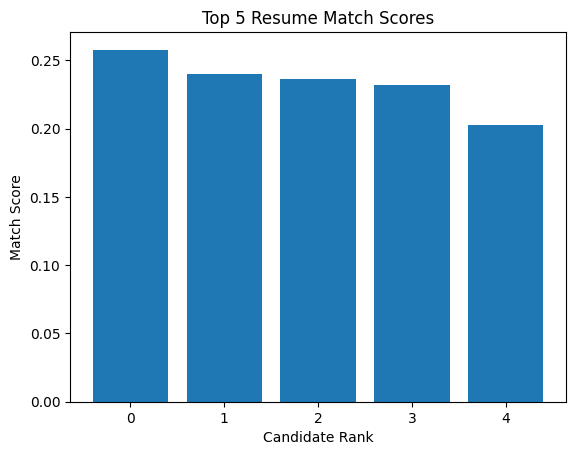

In [55]:
plt.bar(range(5), ranked_resumes['score'].head(5))
plt.xlabel("Candidate Rank")
plt.ylabel("Match Score")
plt.title("Top 5 Resume Match Scores")
plt.show()

In [56]:
ranked_resumes[['skills', 'missing_skills', 'score']].head(5)

,skills,missing_skills,score
1218,"[python, machine learning, java, data analysis...","[statistics, tableau, power bi, excel, pandas,...",0.257864
1303,"[tableau, python, power bi, excel, java, sql]","[numpy, machine learning, pandas, statistics]",0.239940
1339,"[statistics, tableau, python, pandas, excel, d...","[power bi, machine learning]",0.236743
1762,"[statistics, tableau, python, machine learning...","[power bi, numpy]",0.232361
926,"[tableau, python, excel, pandas, java, sql]","[power bi, machine learning, numpy, statistics]",0.202622


In [57]:
print(job_skills)

['statistics', 'tableau', 'python', 'machine learning', 'pandas', 'excel', 'power bi', 'sql', 'numpy']


In [58]:
resumes[['skills']].head()

,skills
0,"[statistics, data analysis]"
1,[]
2,[excel]
3,[excel]
4,[excel]


<BarContainer object of 5 artists>

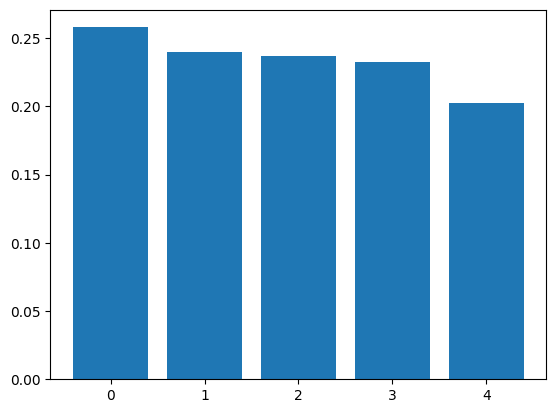

In [59]:
plt.bar(range(5), ranked_resumes['score'].head(5))

In [60]:
resumes[['clean_resume']].head(1)

,clean_resume
0,hr administratormarketing associate ...
